In [1]:
import numpy as np
import pandas as pd
import pywt
import plotly.graph_objects as go

In [2]:
# Generate signal
t = np.linspace(0, 1, 400)
signal = np.sin(30 * t) + np.sin(5 * t)
# Compute CWT
scales = np.arange(1, 50)
coeffs, freqs = pywt.cwt(signal, scales, wavelet='morl')
# Create Plotly heatmap
fig = go.Figure(data=go.Heatmap(
    z=np.abs(coeffs),
    x=t,
    y=scales,
    colorscale='Viridis',
    colorbar=dict(title='Amplitude')
))
fig.update_layout(
title='CWT Time-Frequency Scalogram',
xaxis_title='Time',
yaxis_title='Scale (Lower = Higher Frequency)',
height=400
)
fig.show()

In [3]:
mean_power = np.mean(np.abs(coeffs), axis=1)
df_wavelet = pd.DataFrame({
f"wavelet_scale_{s}": [p] for s, p in zip(scales, mean_power)
})

In [4]:
df_wavelet

,wavelet_scale_1,wavelet_scale_2,wavelet_scale_3,wavelet_scale_4,wavelet_scale_5,wavelet_scale_6,wavelet_scale_7,wavelet_scale_8,wavelet_scale_9,wavelet_scale_10,...,wavelet_scale_40,wavelet_scale_41,wavelet_scale_42,wavelet_scale_43,wavelet_scale_44,wavelet_scale_45,wavelet_scale_46,wavelet_scale_47,wavelet_scale_48,wavelet_scale_49
0,0.001582,0.002201,0.003819,0.006614,0.009975,0.012144,0.01727,0.019656,0.025863,0.028685,...,0.96422,1.098877,1.248406,1.393403,1.573369,1.757108,1.957126,2.164298,2.372893,2.61052


In [5]:
from scipy.signal import convolve
import plotly.graph_objects as go

# Define Gaussian kernel
kernel = np.exp(-np.linspace(-2, 2, 21)**2)
kernel /= kernel.sum()
# Apply to signal
smoothed = convolve(signal, kernel, mode='same')
# Plot original and smoothed signal
fig = go.Figure()
fig.add_trace(go.Scatter(x=t, y=signal, mode='lines', name='Original Signal'))
fig.add_trace(go.Scatter(x=t, y=smoothed, mode='lines', name='Gaussian Smoothed'))
fig.update_layout(title='Signal and Gaussian Convolution', height=400)
fig.show()

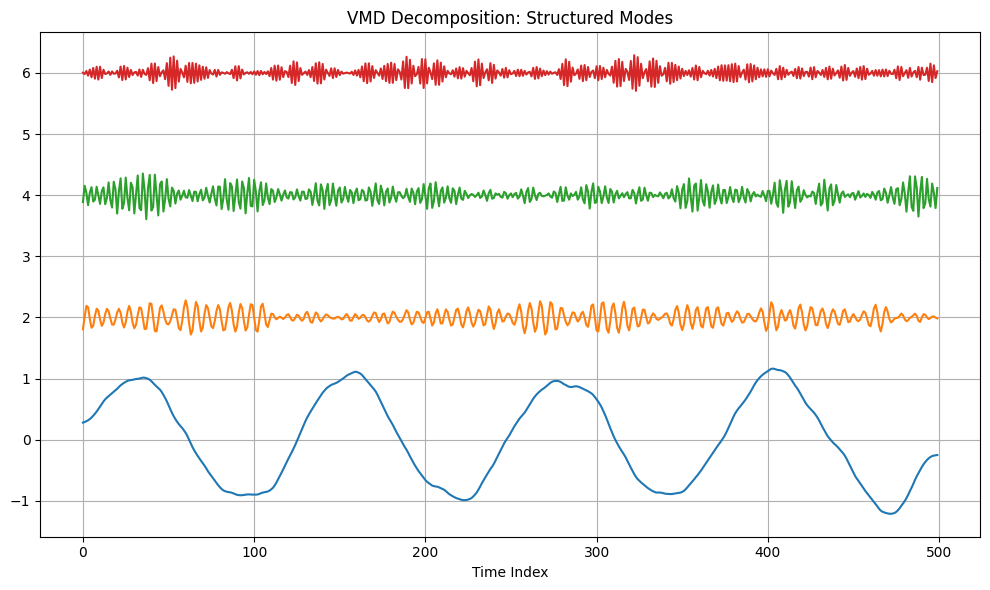

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from vmdpy import VMD # pip install vmdpy

# Generate synthetic signal
t = np.linspace(0, 1, 500)
signal = np.sin(2 * np.pi * 4 * t) + 0.4 * np.random.randn(500)

# VMD parameters
alpha = 2000
tau = 0.
K = 4
DC = 0
init = 1
tol = 1e-7

# Apply VMD (corrected unpacking for latest vmdpy version)
u, u_hat, omega = VMD(signal, alpha, tau, K, DC, init, tol)

# Plot modes
plt.figure(figsize=(10, 6))
for i in range(K):
    plt.plot(u[i] + i * 2, label=f"Mode {i+1}")
plt.title("VMD Decomposition: Structured Modes")
plt.xlabel("Time Index")
plt.tight_layout()
plt.grid(True)
plt.show()

In [7]:
import numpy as np
from scipy.integrate import solve_ivp
import plotly.graph_objects as go

# Lorenz system definition
def lorenz(t, state, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# Initial conditions: two nearly identical points
x0 = [1.0, 1.0, 1.0]
x1 = [1.00001, 1.0, 1.0] # small perturbation

# Integration time
t_span = (0, 30)
t_eval = np.linspace(*t_span, 5000)

# Integrate both trajectories
sol0 = solve_ivp(lorenz, t_span, x0, t_eval=t_eval, method='RK45')
sol1 = solve_ivp(lorenz, t_span, x1, t_eval=t_eval, method='RK45')

# Compute Euclidean distance between trajectories
dist = np.linalg.norm(sol0.y - sol1.y, axis=0)
dist = np.where(dist == 0, 1e-12, dist) # avoid log(0)

# Create interactive plot with Plotly
fig = go.Figure()
fig.add_trace(go.Scatter(x=t_eval, y=np.log(dist), mode='lines', name='log|delta(t)|'))

fig.update_layout(
    title='Divergence of Nearby Trajectories (Lyapunov Exponent)',
    xaxis_title='Time',
    yaxis_title='log|delta(t)|',
    template='plotly_white'
    )

fig.show()

In [8]:
import numpy as np
from nolitsa import lyapunov, delay

# Generate logistic map with chaos
N = 1000
x = np.empty(N)
x[0] = 0.4
r = 3.99 # chaotic regime

for i in range(1, N):
    x[i] = r * x[i - 1] * (1 - x[i - 1])

# Delay embedding
X = delay.embed(x, d=3, tau=1)

# Estimate divergence
l_exp = lyapunov.mle_embed(X, maxt=20)
print("Estimated Lyapunov Exponent:", l_exp)

ModuleNotFoundError: No module named 'nolitsa'

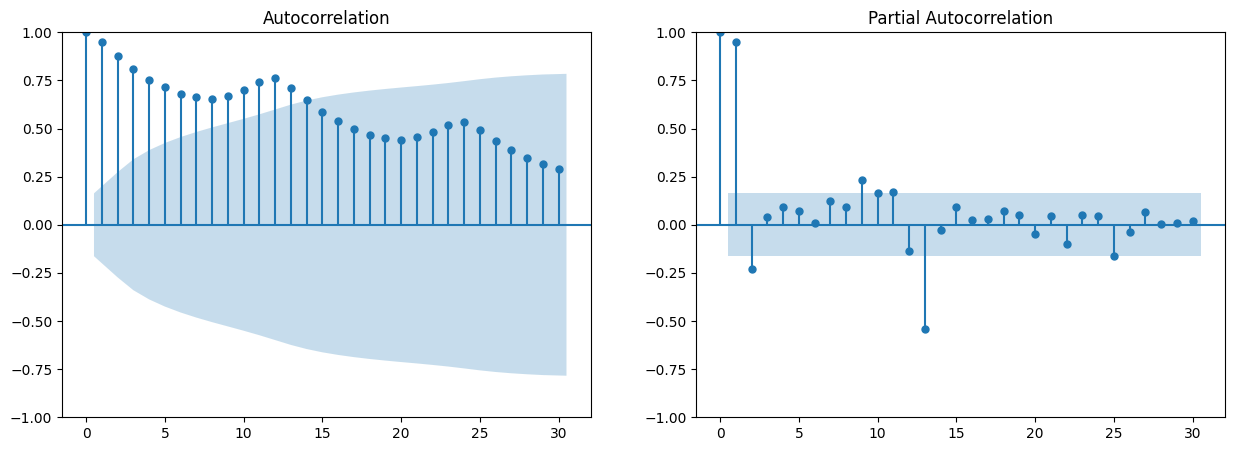

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
data = pd.read_csv(
    'https://raw.githubusercontent.com/valeman/Mastering-Modern-Time-Series-Forecasting-The-Complete-Guide/refs/heads/main/datasets/airline-passengers.csv',
    parse_dates=['Month'], index_col='Month'
    )
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(data['Passengers'], lags=30, ax=axes[0])
plot_pacf(data['Passengers'], lags=30, ax=axes[1])
plt.show()